In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [98]:
df = pd.read_csv("../data/processed/gold_cleaned.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

print(df.shape)
df.head()

(775, 5)


,date,open,high,low,close
0,2023-04-03,1970.84,1990.64,1949.82,1984.11
1,2023-04-04,1984.59,2025.19,1977.01,2019.97
2,2023-04-05,2020.44,2032.20,2009.99,2020.35
3,2023-04-06,2020.13,2021.63,2000.88,2008.02
4,2023-04-10,2008.30,2011.17,1981.59,1989.95


In [99]:
train_df = df[(df["date"] >= "2023-04-03") & (df["date"] <= "2025-03-31")].copy()
val_df   = df[(df["date"] >= "2025-04-01") & (df["date"] <= "2025-09-30")].copy()
test_df  = df[(df["date"] >= "2025-10-01") & (df["date"] <= "2026-04-08")].copy()


train_df["date"] = pd.to_datetime(train_df["date"])
val_df["date"] = pd.to_datetime(val_df["date"])
test_df["date"] = pd.to_datetime(test_df["date"])

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

Train shape: (510, 5)
Validation shape: (130, 5)
Test shape: (135, 5)


In [100]:
def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    }

In [101]:
# Baseline models: Naive Forecast and Moving Average
def naive_forecast(train_close, future_close):
    predictions = []
    history = pd.concat([train_close, future_close]).reset_index(drop=True)
    start_idx = len(train_close)

    for i in range(start_idx, len(history)):
        pred = history.iloc[i - 1]
        predictions.append(pred)

    return np.array(predictions)


def moving_average_forecast(train_close, future_close, window=3):
    predictions = []
    history = pd.concat([train_close, future_close]).reset_index(drop=True)
    start_idx = len(train_close)

    for i in range(start_idx, len(history)):
        pred = history.iloc[i - window:i].mean()
        predictions.append(pred)

    return np.array(predictions)

In [102]:
# Chuẩn bị dữ liệu cho Prophet
prophet_train = train_df[["date", "close"]].copy()
prophet_train = prophet_train.rename(columns={"date": "ds", "close": "y"})

prophet_train.head()

,ds,y
0,2023-04-03,1984.11
1,2023-04-04,2019.97
2,2023-04-05,2020.35
3,2023-04-06,2008.02
4,2023-04-10,1989.95


In [103]:
# Khởi tạo mô hình Prophet đơn giản
model = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True
)

In [104]:
# Huấn luyện mô hình
model.fit(prophet_train)

20:44:58 - cmdstanpy - INFO - Chain [1] start processing
20:44:58 - cmdstanpy - INFO - Chain [1] done processing


In [105]:
# Dự báo trên tập validation
val_future = val_df[["date"]].copy()
val_future = val_future.rename(columns={"date": "ds"})

val_forecast = model.predict(val_future)
val_forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2025-04-01,3018.561781,3078.898873,3154.201537,3018.561781,3018.561781,98.082774,98.082774,98.082774,-19.198937,-19.198937,-19.198937,117.281711,117.281711,117.281711,0.0,0.0,0.0,3116.644555
1,2025-04-02,3020.493166,3084.762667,3159.598844,3020.493166,3020.493166,101.039641,101.039641,101.039641,-21.006366,-21.006366,-21.006366,122.046007,122.046007,122.046007,0.0,0.0,0.0,3121.532808
2,2025-04-03,3022.424552,3092.843137,3168.042971,3022.424552,3022.424552,108.918707,108.918707,108.918707,-17.556288,-17.556288,-17.556288,126.474995,126.474995,126.474995,0.0,0.0,0.0,3131.343259
3,2025-04-04,3024.355938,3100.249315,3175.605815,3024.355938,3024.355938,113.917711,113.917711,113.917711,-16.638763,-16.638763,-16.638763,130.556474,130.556474,130.556474,0.0,0.0,0.0,3138.273649
4,2025-04-07,3030.150095,3112.962021,3187.522183,3029.918188,3030.418266,118.168201,118.168201,118.168201,-22.479838,-22.479838,-22.479838,140.648039,140.648039,140.648039,0.0,0.0,0.0,3148.318296


In [106]:
# Tính toán các chỉ số đánh giá trên tập validation
val_prophet_pred = val_forecast["yhat"].values
val_prophet_metrics = calculate_metrics(val_df["close"].values, val_prophet_pred)

val_prophet_metrics

{'MAE': 145.6158329637654,
 'RMSE': np.float64(179.1477373428489),
 'MAPE': np.float64(4.205752218199881)}

In [107]:
# Vẽ biểu đồ so sánh actual vs predicted trên tập validation
import matplotlib.dates as mdates

def plot_forecast(date_series, actual, predicted_list, labels, title):
    date_series = pd.to_datetime(date_series)

    plt.figure(figsize=(12, 5))
    plt.plot(date_series, actual, label="Actual")

    for pred, label in zip(predicted_list, labels):
        plt.plot(date_series, pred, label=label)

    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Close Price")

    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

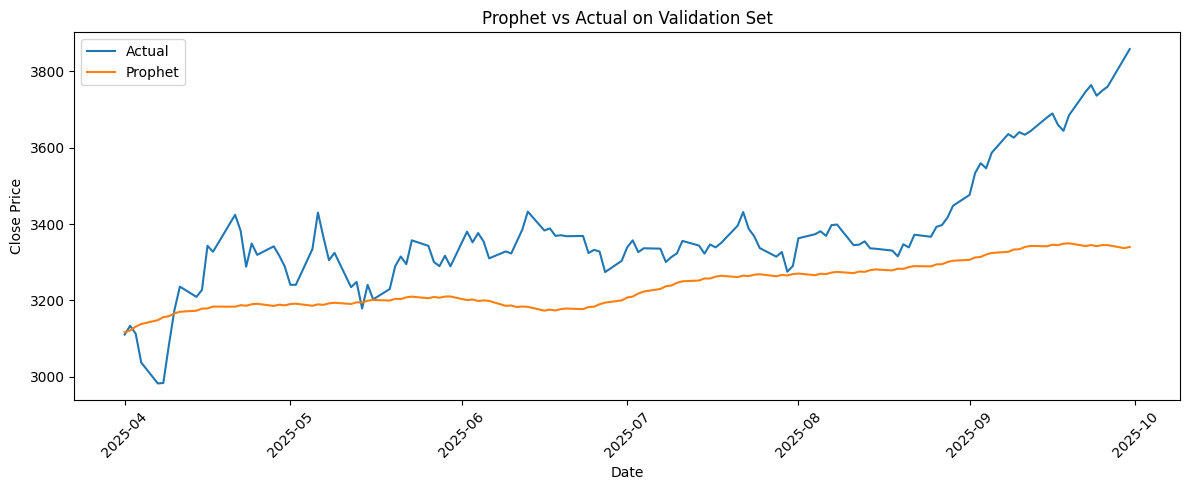

In [108]:
# Vẽ biểu đồ so sánh actual vs predicted trên tập validation
plot_forecast(
    val_df["date"],
    val_df["close"],
    [val_prophet_pred],
    ["Prophet"],
    "Prophet vs Actual on Validation Set"
)

In [109]:
# Kết hợp train + val để huấn luyện lại mô hình trước khi dự báo trên test
train_val_df = pd.concat([train_df, val_df]).reset_index(drop=True)

prophet_train_val = train_val_df[["date", "close"]].copy()
prophet_train_val = prophet_train_val.rename(columns={"date": "ds", "close": "y"})

In [110]:
# Huấn luyện lại mô hình trên tập train + val
model_test = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True
)

model_test.fit(prophet_train_val)

20:44:58 - cmdstanpy - INFO - Chain [1] start processing
20:44:59 - cmdstanpy - INFO - Chain [1] done processing


In [111]:
# Dự báo trên tập test
test_future = test_df[["date"]].copy()
test_future = test_future.rename(columns={"date": "ds"})

test_forecast = model_test.predict(test_future)
test_prophet_pred = test_forecast["yhat"].values

test_prophet_metrics = calculate_metrics(test_df["close"].values, test_prophet_pred)
test_prophet_metrics

{'MAE': 395.40841290184954,
 'RMSE': np.float64(479.1973963647014),
 'MAPE': np.float64(8.406964498193597)}

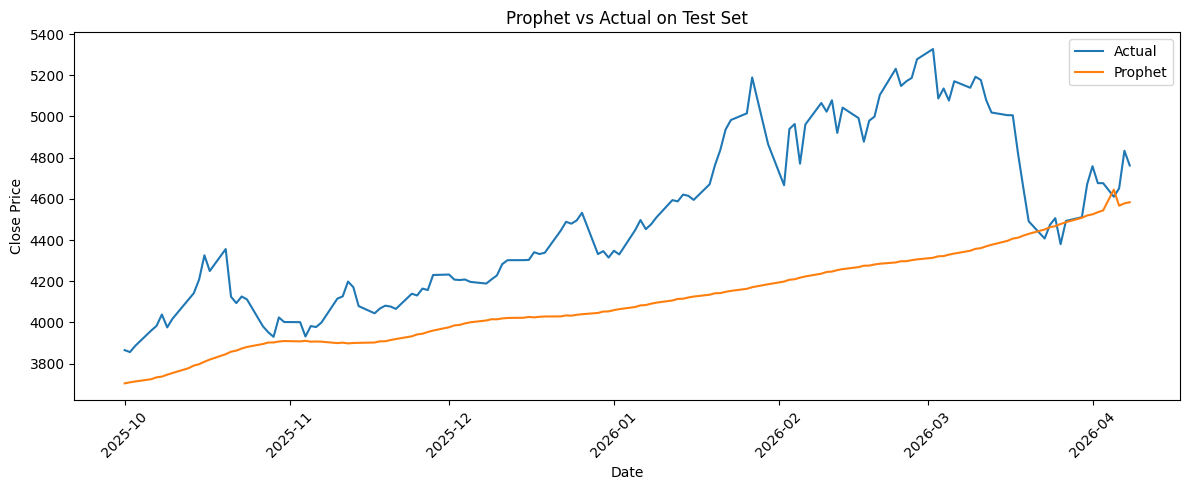

In [112]:
# Vẽ biểu đồ so sánh actual vs predicted trên tập test
plot_forecast(
    test_df["date"],
    test_df["close"],
    [test_prophet_pred],
    ["Prophet"],
    "Prophet vs Actual on Test Set"
)

In [113]:
# Tổng hợp kết quả đánh giá trên tập validation
print("=== Bảng kết quả Prophet trên tập validation ===")
prophet_val_results = pd.DataFrame([
    {"Model": "Prophet", **val_prophet_metrics}
]).round(4)

prophet_val_results

=== Bảng kết quả Prophet trên tập validation ===


,Model,MAE,RMSE,MAPE
0,Prophet,145.6158,179.1477,4.2058


In [114]:
# Tổng hợp kết quả đánh giá trên tập test
print("=== Bảng kết quả Prophet trên tập test ===")
prophet_test_results = pd.DataFrame([
    {"Model": "Prophet", **test_prophet_metrics}
]).round(4)

prophet_test_results

=== Bảng kết quả Prophet trên tập test ===


,Model,MAE,RMSE,MAPE
0,Prophet,395.4084,479.1974,8.407


In [115]:
# So sánh với các baseline đã lưu kết quả
baseline_val_results = pd.read_csv("../outputs/tables/baseline_validation_results.csv")
baseline_test_results = pd.read_csv("../outputs/tables/baseline_test_results.csv")

baseline_val_results
baseline_test_results

,Model,MAE,RMSE,MAPE
0,Naive Forecast,64.5568,89.2788,1.4052
1,Moving Average (3),79.4988,105.1784,1.7446


In [116]:
# Kết hợp với kết quả của Prophet để so sánh trên tập validation
prophet_val_row = pd.DataFrame([
    {"Model": "Prophet", **val_prophet_metrics}
]).round(4)

print("Kết quả so sánh mô hình trên tập validation")
val_compare_results = pd.concat(
    [baseline_val_results, prophet_val_row],
    ignore_index=True
).round(4)

val_compare_results

Kết quả so sánh mô hình trên tập validation


,Model,MAE,RMSE,MAPE
0,Naive Forecast,31.5380,40.5392,0.9408
1,Moving Average (3),39.1290,51.3382,1.1666
2,Prophet,145.6158,179.1477,4.2058


In [117]:
# Kết hợp với kết quả của Prophet để so sánh trên tập test
prophet_test_row = pd.DataFrame([
    {"Model": "Prophet", **test_prophet_metrics}
]).round(4)

print("Kết quả so sánh mô hình trên tập test")
test_compare_results = pd.concat(
    [baseline_test_results, prophet_test_row],
    ignore_index=True
).round(4)

test_compare_results

Kết quả so sánh mô hình trên tập test


,Model,MAE,RMSE,MAPE
0,Naive Forecast,64.5568,89.2788,1.4052
1,Moving Average (3),79.4988,105.1784,1.7446
2,Prophet,395.4084,479.1974,8.4070


In [118]:
# Dự báo baseline trên tập validation
val_naive_pred = naive_forecast(train_df["close"], val_df["close"])
val_ma3_pred = moving_average_forecast(train_df["close"], val_df["close"], window=3)

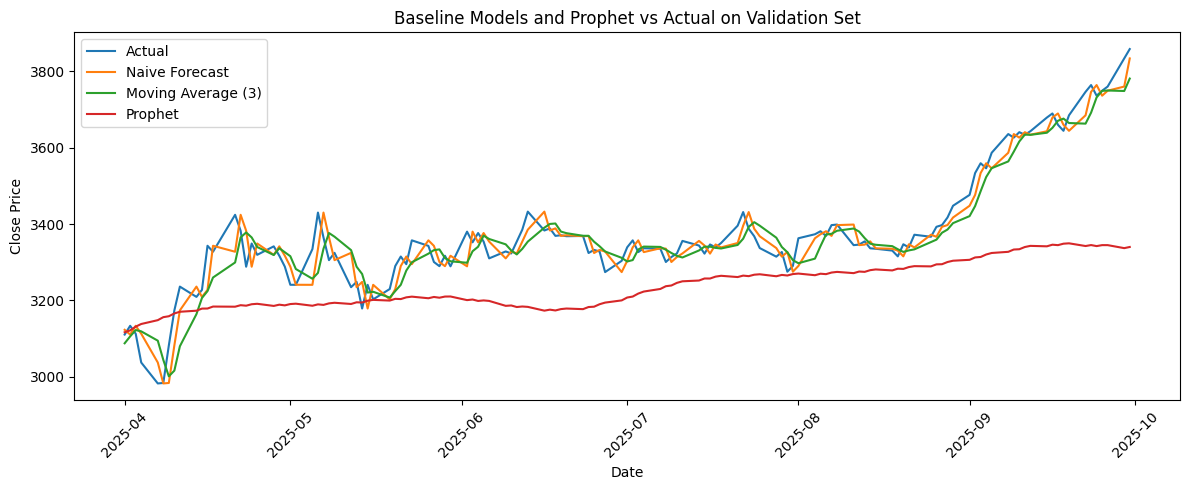

In [119]:
# Vẽ biểu đồ so sánh actual vs predicted trên tập validation cho tất cả các model
plot_forecast(
    val_df["date"],
    val_df["close"],
    [val_naive_pred, val_ma3_pred, val_prophet_pred],
    ["Naive Forecast", "Moving Average (3)", "Prophet"],
    "Baseline Models and Prophet vs Actual on Validation Set"
)

In [120]:
# Dự báo baseline trên tập test
train_val_close = pd.concat([train_df["close"], val_df["close"]]).reset_index(drop=True)

test_naive_pred = naive_forecast(train_val_close, test_df["close"])
test_ma3_pred = moving_average_forecast(train_val_close, test_df["close"], window=3)

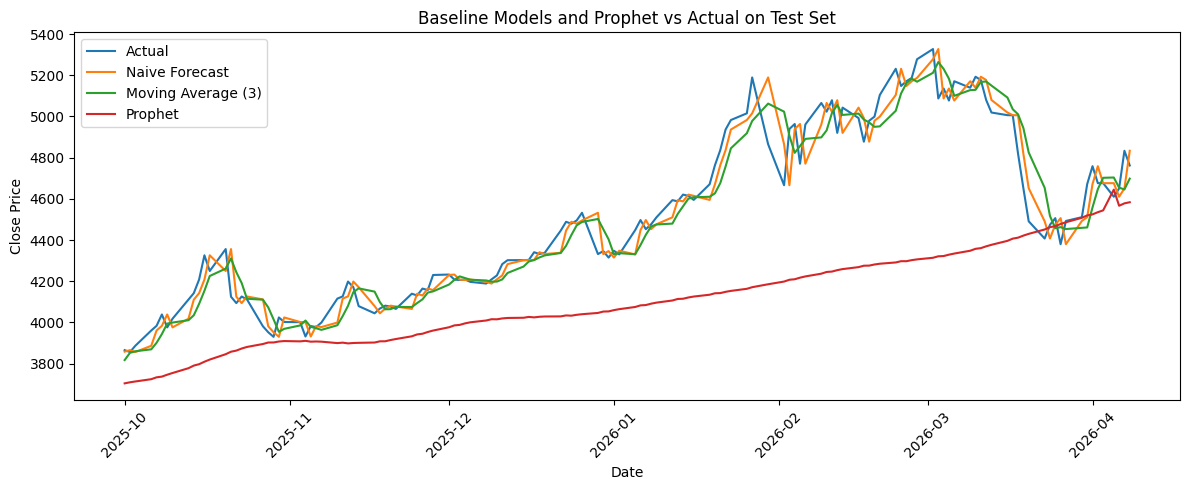

In [121]:
# Vẽ biểu đồ so sánh actual vs predicted trên tập test cho tất cả các model
plot_forecast(
    test_df["date"],
    test_df["close"],
    [test_naive_pred, test_ma3_pred, test_prophet_pred],
    ["Naive Forecast", "Moving Average (3)", "Prophet"],
    "Baseline Models and Prophet vs Actual on Test Set"
)

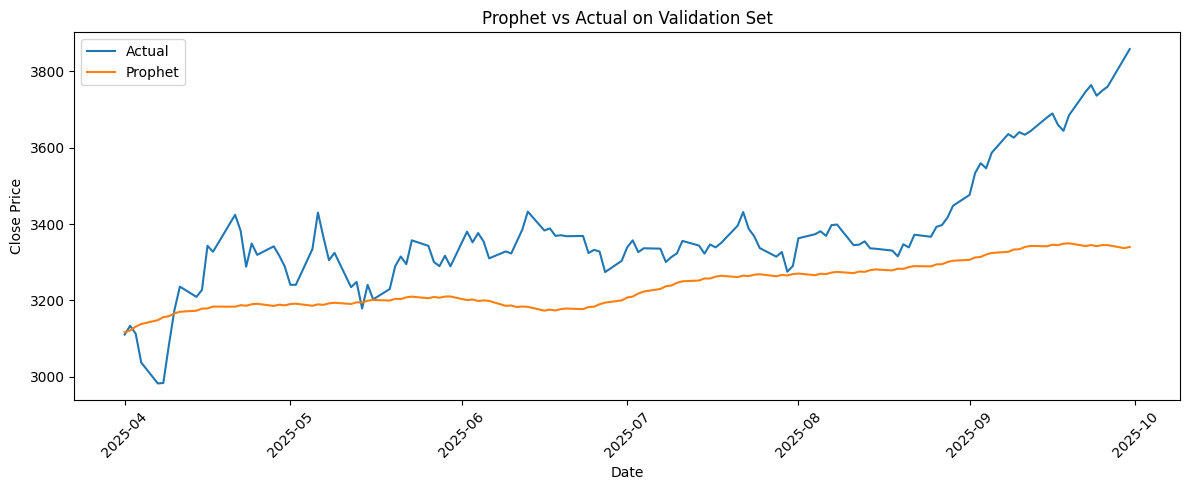

In [122]:
plot_forecast(
    val_df["date"],
    val_df["close"],
    [val_prophet_pred],
    ["Prophet"],
    "Prophet vs Actual on Validation Set"
)

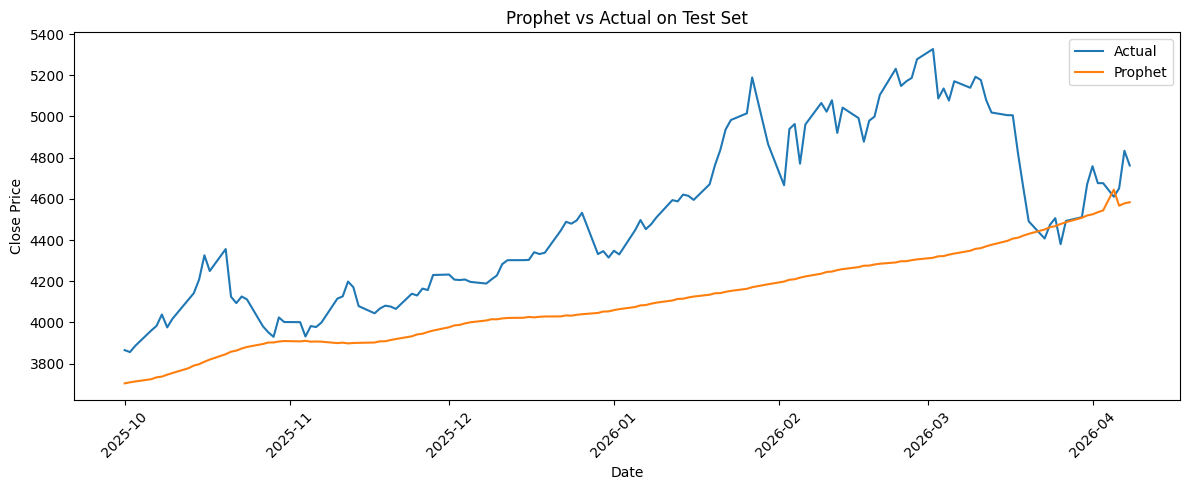

In [123]:
plot_forecast(
    test_df["date"],
    test_df["close"],
    [test_prophet_pred],
    ["Prophet"],
    "Prophet vs Actual on Test Set"
)

In [124]:
# Tuning hyperparameters của Prophet
# Cấu hình 1: Tăng độ nhạy với changepoint
model = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True,
    changepoint_prior_scale=0.5
)

In [125]:
prophet_configs = [
    {"name": "Prophet_Default", "cps": 0.05, "cpr": 0.80, "weekly": True},
    {"name": "Prophet_CPS_0.1", "cps": 0.1, "cpr": 0.80, "weekly": True},
    {"name": "Prophet_CPS_0.3", "cps": 0.3, "cpr": 0.80, "weekly": True},
    {"name": "Prophet_CPS_0.3_CPR_0.95", "cps": 0.3, "cpr": 0.95, "weekly": True},
    {"name": "Prophet_CPS_0.3_CPR_0.95_NoWeekly", "cps": 0.3, "cpr": 0.95, "weekly": False},
]

prophet_val_rows = []

for cfg in prophet_configs:
    model = Prophet(
        daily_seasonality=False,
        weekly_seasonality=cfg["weekly"],
        yearly_seasonality=True,
        changepoint_prior_scale=cfg["cps"],
        changepoint_range=cfg["cpr"]
    )
    
    model.fit(prophet_train)

    val_future = val_df[["date"]].copy().rename(columns={"date": "ds"})
    val_forecast = model.predict(val_future)

    preds = val_forecast["yhat"].values
    metrics = calculate_metrics(val_df["close"].values, preds)

    prophet_val_rows.append({
        "Model": cfg["name"],
        "changepoint_prior_scale": cfg["cps"],
        "changepoint_range": cfg["cpr"],
        "weekly_seasonality": cfg["weekly"],
        **metrics
    })

prophet_tuning_results = pd.DataFrame(prophet_val_rows).round(4)
prophet_tuning_results

20:45:00 - cmdstanpy - INFO - Chain [1] start processing
20:45:00 - cmdstanpy - INFO - Chain [1] done processing
20:45:00 - cmdstanpy - INFO - Chain [1] start processing
20:45:00 - cmdstanpy - INFO - Chain [1] done processing
20:45:00 - cmdstanpy - INFO - Chain [1] start processing
20:45:00 - cmdstanpy - INFO - Chain [1] done processing
20:45:00 - cmdstanpy - INFO - Chain [1] start processing
20:45:01 - cmdstanpy - INFO - Chain [1] done processing
20:45:01 - cmdstanpy - INFO - Chain [1] start processing
20:45:01 - cmdstanpy - INFO - Chain [1] done processing


,Model,changepoint_prior_scale,changepoint_range,weekly_seasonality,MAE,RMSE,MAPE
0,Prophet_Default,0.05,0.80,True,145.6158,179.1477,4.2058
1,Prophet_CPS_0.1,0.10,0.80,True,310.8935,346.4650,9.0345
2,Prophet_CPS_0.3,0.30,0.80,True,84.8130,106.2229,2.4726
3,Prophet_CPS_0.3_CPR_0.95,0.30,0.95,True,404.8261,449.0621,11.7723
4,Prophet_CPS_0.3_CPR_0.95_NoWeekly,0.30,0.95,False,511.5425,571.4218,14.8700


In [126]:
prophet_train_log = train_df[["date", "close"]].copy()
prophet_train_log["close"] = np.log(prophet_train_log["close"])
prophet_train_log = prophet_train_log.rename(columns={"date": "ds", "close": "y"})

model_log = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True,
    changepoint_prior_scale=0.3
)

model_log.fit(prophet_train_log)

val_future = val_df[["date"]].copy().rename(columns={"date": "ds"})
val_forecast_log = model_log.predict(val_future)

val_prophet_log_pred = np.exp(val_forecast_log["yhat"].values)
val_prophet_log_metrics = calculate_metrics(val_df["close"].values, val_prophet_log_pred)

val_prophet_log_metrics

20:45:01 - cmdstanpy - INFO - Chain [1] start processing
20:45:01 - cmdstanpy - INFO - Chain [1] done processing


{'MAE': 1742.1901192935304,
 'RMSE': np.float64(2088.3407738671626),
 'MAPE': np.float64(50.503950825498165)}

In [127]:
prophet_val_results.to_csv("../outputs/tables/prophet_validation_results.csv", index=False)
prophet_test_results.to_csv("../outputs/tables/prophet_test_results.csv", index=False)

In [128]:
val_compare_results.to_csv("../outputs/tables/all_models_validation_results.csv", index=False)
test_compare_results.to_csv("../outputs/tables/all_models_test_results.csv", index=False)